# 04 — Autoencoder-based unsupervised seizure embedding

This notebook uses a small PyTorch autoencoder to learn a nonlinear 2D latent representation of seizure event features.

This is unsupervised: no condition/stage labels are used during training.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", None)

output_dir = Path("../outputs/seizure_analysis")
fig_dir = output_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

events_path = output_dir / "seizure_events_clean.csv"
events = pd.read_csv(events_path)

feature_cols = [
    "amplitude",
    "FWHM",
    "prominence",
    "AUC",
    "rise",
    "decay",
    "duration"
]

df = events.dropna(subset=feature_cols).copy()

X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

print(df.shape)
print(X_scaled.shape)

(527, 14)
(527, 7)


In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class SeizureAutoencoder(nn.Module):

    def __init__(self, input_dim, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


model = SeizureAutoencoder(
    input_dim=X_scaled.shape[1],
    latent_dim=2
).to(device)

print(model)

SeizureAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=7, bias=True)
  )
)


Epoch 50/300, loss=0.192051
Epoch 100/300, loss=0.138618
Epoch 150/300, loss=0.117592
Epoch 200/300, loss=0.104156
Epoch 250/300, loss=0.087165
Epoch 300/300, loss=0.076562


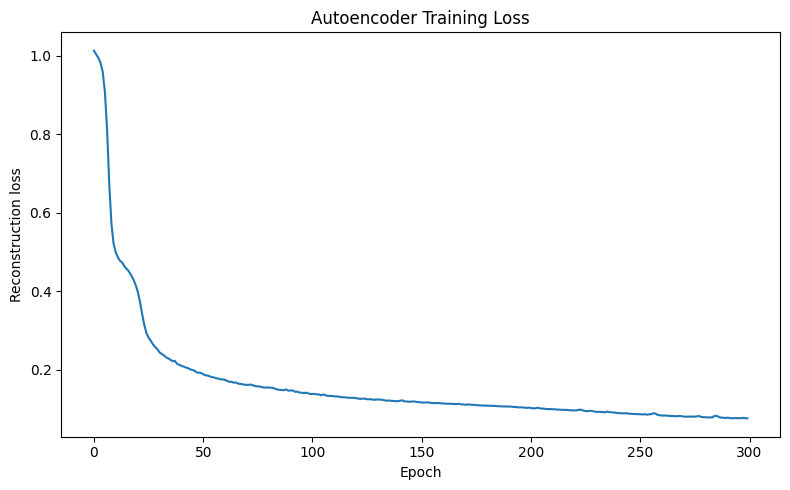

In [4]:
tensor_data = torch.tensor(X_scaled)
dataset = TensorDataset(tensor_data)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

loss_fn = nn.MSELoss()

n_epochs = 300

loss_history = []

for epoch in range(n_epochs):

    model.train()

    epoch_loss = 0.0

    for batch in loader:

        x_batch = batch[0].to(device)

        optimizer.zero_grad()

        x_hat, z = model(x_batch)

        loss = loss_fn(x_hat, x_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= len(dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, loss={epoch_loss:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Autoencoder Training Loss")
plt.tight_layout()
plt.savefig(fig_dir / "autoencoder_training_loss.tiff", dpi=300, format="tiff")
plt.show()

In [5]:
model.eval()

with torch.no_grad():
    x_tensor = torch.tensor(X_scaled).to(device)
    x_hat, z = model(x_tensor)

latent = z.cpu().numpy()
reconstruction = x_hat.cpu().numpy()

df_latent = df[
    ["source_row", "event_id", "animal", "condition", "stage"]
].copy()

df_latent["latent_1"] = latent[:, 0]
df_latent["latent_2"] = latent[:, 1]

display(df_latent.head())

,source_row,event_id,animal,condition,stage,latent_1,latent_2
0,2,0,M15,Sham,pre_CSD,-0.647633,0.591110
1,3,1,M15,Sham,pre_CSD,-0.577542,0.443098
2,5,2,M15,Sham,pre_CSD,-1.936336,0.710860
3,7,3,M15,Sham,pre_CSD,-3.606796,1.109985
4,8,4,M15,Sham,pre_CSD,-2.217881,0.840467


,method,k,silhouette
0,kmeans_autoencoder,2,0.674192
1,hierarchical_autoencoder,2,0.650478
2,kmeans_autoencoder,3,0.647032
3,hierarchical_autoencoder,3,0.642110
4,kmeans_autoencoder,4,0.399529
5,hierarchical_autoencoder,4,0.321631
6,kmeans_autoencoder,5,0.478877
7,hierarchical_autoencoder,5,0.336325
8,kmeans_autoencoder,6,0.483048
9,hierarchical_autoencoder,6,0.336304


Saved: ../outputs/seizure_analysis/autoencoder_clustering_k_metrics.csv


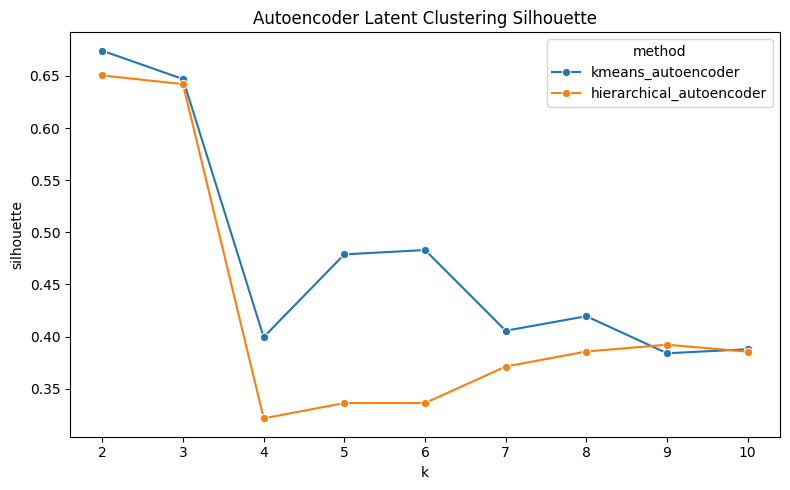

In [6]:
cluster_range = range(2, 11)

rows = []

for k in cluster_range:

    labels_km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    ).fit_predict(latent)

    labels_h = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    ).fit_predict(latent)

    rows.append({
        "method": "kmeans_autoencoder",
        "k": k,
        "silhouette": silhouette_score(latent, labels_km)
    })

    rows.append({
        "method": "hierarchical_autoencoder",
        "k": k,
        "silhouette": silhouette_score(latent, labels_h)
    })

ae_metrics = pd.DataFrame(rows)

display(ae_metrics)

ae_metrics_path = output_dir / "autoencoder_clustering_k_metrics.csv"
ae_metrics.to_csv(ae_metrics_path, index=False)

print("Saved:", ae_metrics_path)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=ae_metrics,
    x="k",
    y="silhouette",
    hue="method",
    marker="o"
)
plt.title("Autoencoder Latent Clustering Silhouette")
plt.tight_layout()
plt.savefig(fig_dir / "autoencoder_latent_silhouette.tiff", dpi=300, format="tiff")
plt.show()

In [7]:
selected_k = 4

labels_ae_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=20
).fit_predict(latent) + 1

labels_ae_hierarchical = AgglomerativeClustering(
    n_clusters=selected_k,
    linkage="ward"
).fit_predict(latent) + 1

df_latent["ae_kmeans_cluster"] = labels_ae_kmeans
df_latent["ae_hierarchical_cluster"] = labels_ae_hierarchical

print("ARI AE KMeans vs AE Hierarchical:")
print(adjusted_rand_score(labels_ae_kmeans, labels_ae_hierarchical))

ARI AE KMeans vs AE Hierarchical:
0.7754335608011785


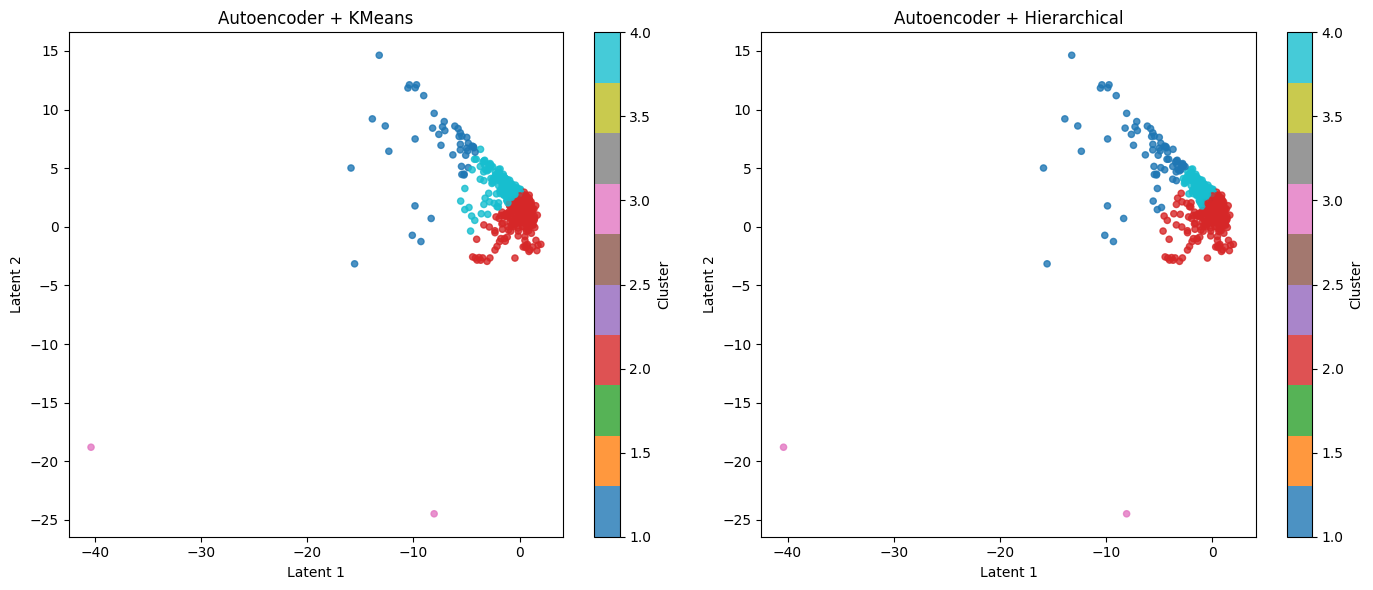

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cluster_col, title in zip(
    axes,
    ["ae_kmeans_cluster", "ae_hierarchical_cluster"],
    ["Autoencoder + KMeans", "Autoencoder + Hierarchical"]
):

    sc = ax.scatter(
        df_latent["latent_1"],
        df_latent["latent_2"],
        c=df_latent[cluster_col],
        s=20,
        alpha=0.8,
        cmap="tab10"
    )

    ax.set_xlabel("Latent 1")
    ax.set_ylabel("Latent 2")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, label="Cluster")

plt.tight_layout()
plt.savefig(fig_dir / "autoencoder_latent_clusters.tiff", dpi=300, format="tiff")
plt.show()

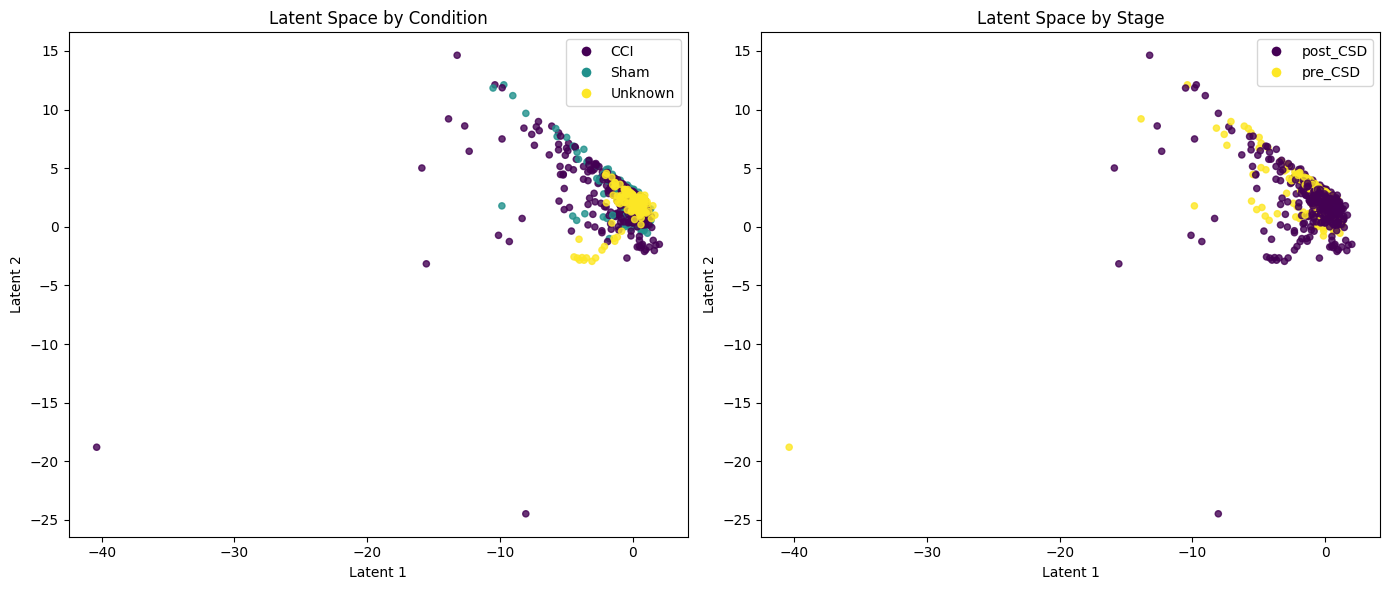

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, color_col, title in zip(
    axes,
    ["condition", "stage"],
    ["Latent Space by Condition", "Latent Space by Stage"]
):

    labels = df_latent[color_col].astype("category")
    codes = labels.cat.codes

    sc = ax.scatter(
        df_latent["latent_1"],
        df_latent["latent_2"],
        c=codes,
        s=20,
        alpha=0.8
    )

    ax.set_xlabel("Latent 1")
    ax.set_ylabel("Latent 2")
    ax.set_title(title)

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=cat,
            markerfacecolor=sc.cmap(sc.norm(code)),
            markersize=8
        )
        for code, cat in enumerate(labels.cat.categories)
    ]
    ax.legend(handles=handles)

plt.tight_layout()
plt.savefig(fig_dir / "autoencoder_latent_metadata.tiff", dpi=300, format="tiff")
plt.show()

In [10]:
latent_path = output_dir / "seizure_autoencoder_latent_assignments.csv"
df_latent.to_csv(latent_path, index=False)

df_with_latent = df.copy()
df_with_latent["latent_1"] = latent[:, 0]
df_with_latent["latent_2"] = latent[:, 1]
df_with_latent["ae_kmeans_cluster"] = labels_ae_kmeans
df_with_latent["ae_hierarchical_cluster"] = labels_ae_hierarchical

full_latent_path = output_dir / "seizure_events_autoencoder_clustered.csv"
df_with_latent.to_csv(full_latent_path, index=False)

print("Saved:")
print(latent_path)
print(full_latent_path)

Saved:
../outputs/seizure_analysis/seizure_autoencoder_latent_assignments.csv
../outputs/seizure_analysis/seizure_events_autoencoder_clustered.csv
